In [1]:
!pip install wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.7/13.7 MB 34.0 MB/s  0:00:00 eta 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [26]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from langdetect import detect, DetectorFactory
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split
import re
from wordcloud import WordCloud
import numpy as np
import nltk
from nltk.corpus import opinion_lexicon
from nltk.util import ngrams
import nltk
nltk.download("stopwords")
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /Users/Khoai/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# 1. Import Data

In [3]:
csv_paths = list(Path("../Dataset/data_new_approach/").glob("*.csv"))

print("CSV files found:")
for p in csv_paths:
    print(p.name)

CSV files found:
marcus_by_goldman_sachs__combined_us.csv
chase__combined_us.csv
bank_of_america__combined_us.csv
wells_fargo__combined_us.csv
citi__combined_us.csv


In [4]:
# import files
raw = pd.concat(
    [
        pd.read_csv(p, dtype=str).assign(source_file=p.name)
        for p in csv_paths
    ],
    ignore_index=True
)

# 2. Data Overview

In [5]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5450 entries, 0 to 5449
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   platform       5450 non-null   object
 1   storefront     5450 non-null   object
 2   app_id         2450 non-null   object
 3   review_id      5450 non-null   object
 4   date           5450 non-null   object
 5   user           5450 non-null   object
 6   rating         5450 non-null   object
 7   title          2450 non-null   object
 8   review         5450 non-null   object
 9   version        2450 non-null   object
 10  package        3000 non-null   object
 11  thumbsUpCount  3000 non-null   object
 12  appVersion     2774 non-null   object
 13  source_file    5450 non-null   object
dtypes: object(14)
memory usage: 596.2+ KB


In [6]:
raw.describe(include = "all")

,platform,storefront,app_id,review_id,date,user,rating,title,review,version,package,thumbsUpCount,appVersion,source_file
count,5450,5450,2450,5450,5450,5450,5450,2450,5450,2450,3000,3000,2774,5450
unique,2,1,5,5450,5450,5400,5,2064,4960,61,5,24,108,5
top,google_play,us,1489511701.0,13976661175,2026-04-19T18:13:04-07:00,A Google user,5,Great,good,4.732,com.marcus.android,0.0,9.93.1,marcus_by_goldman_sachs__combined_us.csv
freq,3000,5450,490,1,1,18,3256,24,54,230,600,2670,479,1090


In [7]:
raw.head()

,platform,storefront,app_id,review_id,date,user,rating,title,review,version,package,thumbsUpCount,appVersion,source_file
0,app_store,us,1489511701.0,13976661175,2026-04-19T18:13:04-07:00,errttrwfdsbvxd,3,No ATM option,No debit card 😣,2.20.0,NaN,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv
1,app_store,us,1489511701.0,13968552342,2026-04-17T13:06:01-07:00,Chi town $&@&$,5,Great Bank.,Really easy bank to use. The best interest rat...,2.20.0,NaN,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv
2,app_store,us,1489511701.0,13967597795,2026-04-17T07:34:37-07:00,Pichu4ever,5,Pato,Great,2.20.0,NaN,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv
3,app_store,us,1489511701.0,13965458699,2026-04-16T16:11:11-07:00,Ann22k,5,Saving or CD,Easy to navigate and transfers back to account...,2.20.0,NaN,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv
4,app_store,us,1489511701.0,13963956841,2026-04-16T06:48:48-07:00,binbincheong,5,Easy peasy,Very easy to use and efficient! Good interest...,2.20.0,NaN,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv


In [8]:
platform_counts = (
    raw
    .groupby("platform")
    .size()
    .reset_index(name="n_reviews")
)

platform_counts

,platform,n_reviews
0,app_store,2450
1,google_play,3000


In [9]:
missing_raw = (
    raw
    .isna()
    .sum()
    .reset_index()
)

missing_raw.columns = ["variable", "n_missing"]

missing_raw = (
    missing_raw
    .sort_values("n_missing", ascending=False)
    .reset_index(drop=True)
)

missing_raw

,variable,n_missing
0,app_id,3000
1,title,3000
2,version,3000
3,appVersion,2676
4,package,2450
5,thumbsUpCount,2450
6,platform,0
7,storefront,0
8,review_id,0
9,date,0


In [10]:
missing_by_platform = (
    raw
    .groupby("platform")
    .agg(lambda col: col.isna().sum())
    .reset_index()
)

missing_by_platform

,platform,storefront,app_id,review_id,date,user,rating,title,review,version,package,thumbsUpCount,appVersion,source_file
0,app_store,0,0,0,0,0,0,0,0,0,2450,2450,2450,0
1,google_play,0,3000,0,0,0,0,3000,0,3000,0,0,226,0


In [11]:
raw["raw_text"] = (
    raw["title"].fillna("") + " " + raw["review"].fillna("")
)

raw["raw_length_words"] = (
    raw["raw_text"]
    .str.count(r"\S+")
)

In [12]:
raw["raw_length_words"].describe()

count    5450.000000
mean       22.044587
std        29.047547
min         1.000000
25%         4.000000
50%        11.000000
75%        28.000000
max       377.000000
Name: raw_length_words, dtype: float64

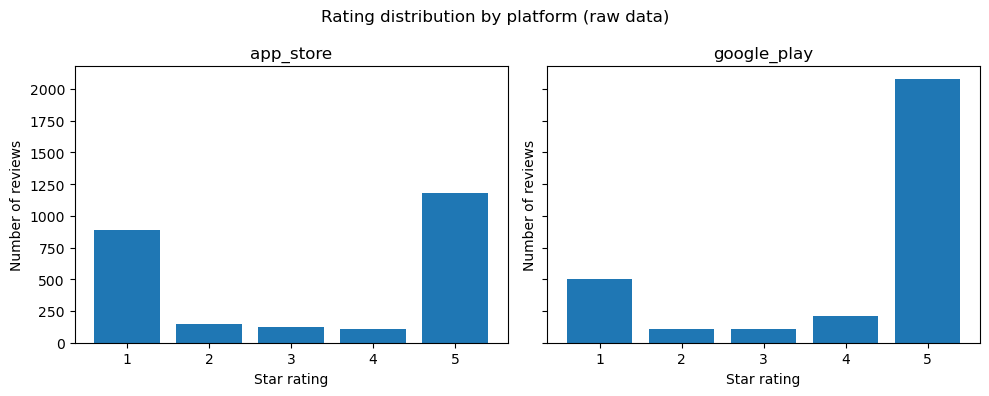

In [13]:
# Count the ratings by platform
rating_counts = (
    raw
    .groupby(["platform", "rating"])
    .size()
    .reset_index(name="n_reviews")
)

platforms = rating_counts["platform"].unique()

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(platforms),
    figsize=(10, 4),
    sharey=True
)

if len(platforms) == 1:
    axes = [axes]

for ax, platform in zip(axes, platforms):
    data = rating_counts[rating_counts["platform"] == platform]

    ax.bar(data["rating"], data["n_reviews"])
    ax.set_title(platform)
    ax.set_xlabel("Star rating")
    ax.set_ylabel("Number of reviews")

fig.suptitle("Rating distribution by platform (raw data)")
plt.tight_layout()
plt.show()

# 3. Data Preprocessing

## 3.1 Preprocessing for Lexicon Based

In [14]:
df1 = raw.copy()

df1["bank"] = (
    df1["source_file"]
    .str.replace(r"__combined_us\.csv$", "", regex=True)
    .str.replace("_", " ", regex=False)
    .str.title()
)

df1["platform"] = df1["platform"].replace({
    "app_store": "iOS",
    "google_play": "Android"
})

df1.groupby(["bank", "platform"]).size().reset_index(name="n")

,bank,platform,n
0,Bank Of America,Android,600
1,Bank Of America,iOS,490
2,Chase,Android,600
3,Chase,iOS,490
4,Citi,Android,600
5,Citi,iOS,490
6,Marcus By Goldman Sachs,Android,600
7,Marcus By Goldman Sachs,iOS,490
8,Wells Fargo,Android,600
9,Wells Fargo,iOS,490


In [15]:
df2 = df1.copy()

df2["rating"] = pd.to_numeric(df2["rating"], errors="coerce")
df2["date"] = pd.to_datetime(df2["date"], errors="coerce")

rating_summary = df2["rating"].agg(
    Min="min",
    Q1=lambda x: x.quantile(0.25),
    Median="median",
    Mean="mean",
    Q3=lambda x: x.quantile(0.75),
    Max="max"
)

date_summary = df2["date"].agg(
    Min="min",
    Q1=lambda x: x.quantile(0.25),
    Median="median",
    Mean="mean",
    Q3=lambda x: x.quantile(0.75),
    Max="max"
)

print("Rating summary:")
print(rating_summary)

print("\nDate summary:")
print(date_summary)

df2.head()

Rating summary:
Min       1.000000
Q1        1.000000
Median    5.000000
Mean      3.697982
Q3        5.000000
Max       5.000000
Name: rating, dtype: float64

Date summary:
Min                2024-06-06 14:25:49-07:00
Q1       2025-12-24 02:06:11.249999872-07:00
Median      2026-03-21 12:18:06.500000-07:00
Mean     2026-01-10 08:49:03.699183616-07:00
Q3       2026-04-07 13:22:56.750000128-07:00
Max                2026-04-20 09:04:39-07:00
Name: date, dtype: datetime64[ns, UTC-07:00]


,platform,storefront,app_id,review_id,date,user,rating,title,review,version,package,thumbsUpCount,appVersion,source_file,raw_text,raw_length_words,bank
0,iOS,us,1489511701.0,13976661175,2026-04-19 18:13:04-07:00,errttrwfdsbvxd,3,No ATM option,No debit card 😣,2.20.0,NaN,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv,No ATM option No debit card 😣,7,Marcus By Goldman Sachs
1,iOS,us,1489511701.0,13968552342,2026-04-17 13:06:01-07:00,Chi town $&@&$,5,Great Bank.,Really easy bank to use. The best interest rat...,2.20.0,NaN,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv,Great Bank. Really easy bank to use. The best ...,13,Marcus By Goldman Sachs
2,iOS,us,1489511701.0,13967597795,2026-04-17 07:34:37-07:00,Pichu4ever,5,Pato,Great,2.20.0,NaN,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv,Pato Great,2,Marcus By Goldman Sachs
3,iOS,us,1489511701.0,13965458699,2026-04-16 16:11:11-07:00,Ann22k,5,Saving or CD,Easy to navigate and transfers back to account...,2.20.0,NaN,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv,Saving or CD Easy to navigate and transfers ba...,18,Marcus By Goldman Sachs
4,iOS,us,1489511701.0,13963956841,2026-04-16 06:48:48-07:00,binbincheong,5,Easy peasy,Very easy to use and efficient! Good interest...,2.20.0,NaN,NaN,NaN,marcus_by_goldman_sachs__combined_us.csv,Easy peasy Very easy to use and efficient! Go...,11,Marcus By Goldman Sachs


In [16]:
DetectorFactory.seed = 0

def detect_language(text):
    text = str(text).strip()
    
    if not text:
        return "unknown"
    
    try:
        return detect(text)
    except:
        return "unknown"


df_lang = df2.copy()
df_lang["language"] = df_lang["raw_text"].apply(detect_language)

language_counts = (
    df_lang["language"]
    .value_counts()
    .reset_index()
)

language_counts.columns = ["language", "n"]

language_counts

,language,n
0,en,4478
1,es,222
2,af,109
3,so,108
4,ro,69
5,ca,68
6,fr,49
7,da,41
8,tl,35
9,no,33


In [17]:
df_english = df_lang[df_lang["language"] == "en"].copy()

total_reviews = len(df2)
english_reviews = len(df_english)
removed_non_english = total_reviews - english_reviews

summary_english = pd.DataFrame({
    "total_reviews": [total_reviews],
    "english_reviews": [english_reviews],
    "removed_non_english": [removed_non_english],
    "pct_removed": [
        100 * removed_non_english / total_reviews if total_reviews > 0 else 0
    ]
})

summary_english

,total_reviews,english_reviews,removed_non_english,pct_removed
0,5450,4478,972,17.834862


In [18]:
custom_words = pd.DataFrame({
    "word": ["app", "bank", "banking", "mobile", "iphone", "apple", "android", "phone"],
    "lexicon": "custom"
})

default_stop_words = pd.DataFrame({
    "word": list(ENGLISH_STOP_WORDS),
    "lexicon": "sklearn"
})

custom_stop_words = pd.concat(
    [custom_words, default_stop_words],
    ignore_index=True
).drop_duplicates(subset=["word"])

custom_stop_words.head()

,word,lexicon
0,app,custom
1,bank,custom
2,banking,custom
3,mobile,custom
4,iphone,custom


In [19]:
reviews_before_sw = df_english.copy()

reviews_before_sw["word"] = (
    reviews_before_sw["raw_text"]
    .fillna("")
    .str.lower()
    .apply(lambda x: re.findall(r"\b[a-z]+\b", x))
)

reviews_before_sw = reviews_before_sw.explode("word")
reviews_before_sw = reviews_before_sw.dropna(subset=["word"])

stop_words_set = set(custom_stop_words["word"].str.lower())

reviews_after_sw = reviews_before_sw[
    ~reviews_before_sw["word"].isin(stop_words_set)
].copy()

tokens_before = len(reviews_before_sw)
tokens_after = len(reviews_after_sw)
tokens_removed = tokens_before - tokens_after

stopword_summary = pd.DataFrame({
    "tokens_before": [tokens_before],
    "tokens_after": [tokens_after],
    "tokens_removed": [tokens_removed],
    "pct_removed": [
        100 * tokens_removed / tokens_before if tokens_before > 0 else 0
    ]
})

stopword_summary

,tokens_before,tokens_after,tokens_removed,pct_removed
0,117097,53094,64003,54.658104


In [20]:
stop_words_set = set(custom_stop_words["word"].str.lower())

removed_words = (
    reviews_before_sw[reviews_before_sw["word"].isin(stop_words_set)]
    .groupby("word")
    .size()
    .reset_index(name="n")
    .sort_values("n", ascending=False)
)

removed_words.head()

,word,n
240,to,4542
220,the,4206
120,i,3842
20,and,3122
129,it,2258


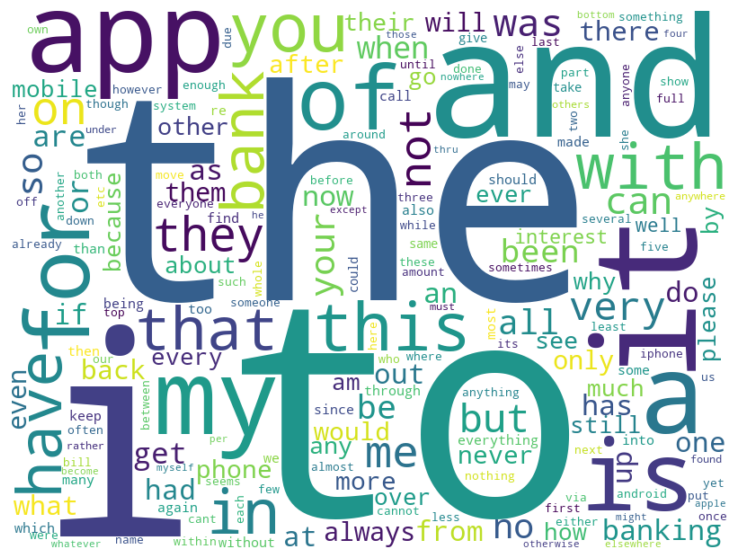

In [21]:
word_freq = dict(zip(removed_words["word"], removed_words["n"]))

wc = WordCloud(
    width=800,
    height=600,
    background_color="white",
    max_words=200
).generate_from_frequencies(word_freq)

plt.figure(figsize=(10, 7))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

In [27]:
negators = {
    "no", "not", "nor", "never", "none", "neither", "cannot",
    "hardly", "rarely", "barely", "dont", "isn't", "wasn't",
    "aren't", "won't", "shouldn't", "couldn't", "wouldn't",
    "doesn't", "didn't", "haven't", "hasn't", "hadn't", "can't", "cant"
}

In [28]:
# Stopwords excluding negators so negators are preserved in bigrams
bigram_stop = (set(stopwords.words("english")) - negators) | {
    "app", "bank", "banking", "mobile",
    "iphone", "apple", "android", "phone"
}

In [29]:
def make_bigrams(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = text.split()
    return list(ngrams(tokens, 2))

In [30]:
bigram_rows = []
for _, row in df_english.iterrows():
    for w1, w2 in make_bigrams(row["raw_text"]):
        if w1 not in bigram_stop and w2 not in bigram_stop:
            bigram_rows.append({
                "review_id": row["review_id"],
                "bank":      row["bank"],
                "platform":  row["platform"],
                "rating":    row["rating"],
                "word1":     w1,
                "word2":     w2
            })

In [31]:
bigrams = pd.DataFrame(bigram_rows)
bigram_counts = (
    bigrams.groupby(["word1", "word2"])
    .size()
    .reset_index(name="n")
    .sort_values("n", ascending=False)
)

print("--- Top 20 bigrams ---")
print(bigram_counts.head(20).to_string(index=False))

--- Top 20 bigrams ---
   word1    word2   n
customer  service 222
   wells    fargo 177
  credit     card 151
    user friendly 117
   every     time  75
      no   longer  66
 savings  account  55
   bring     back  42
   great  service  42
    dark     mode  41
interest     rate  40
    face       id  39
  credit    cards  38
  please      fix  38
   blank   screen  37
    even   though  36
interest    rates  33
     new   update  33
checking  account  32
   debit     card  30


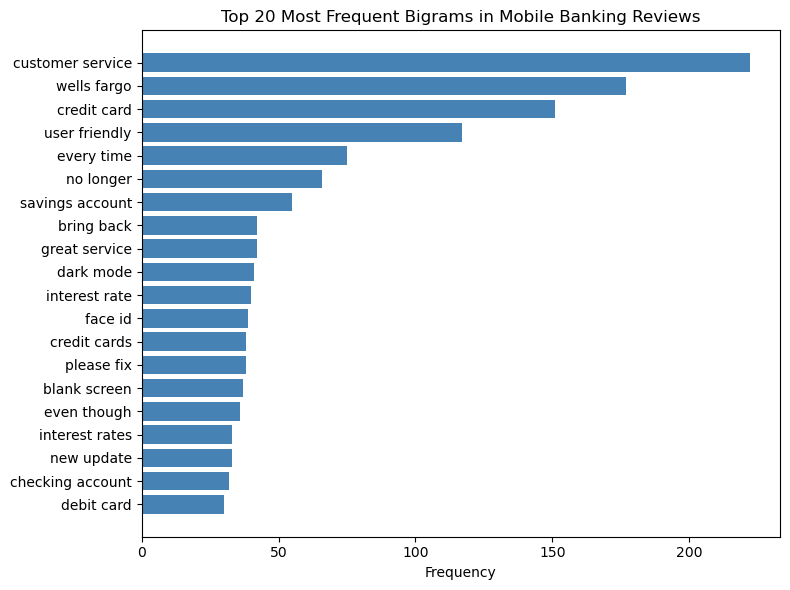

In [32]:
top20_bigrams = bigram_counts.head(20).copy()
top20_bigrams["bigram"] = top20_bigrams["word1"] + " " + top20_bigrams["word2"]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top20_bigrams["bigram"][::-1], top20_bigrams["n"][::-1], color="steelblue")
ax.set_xlabel("Frequency")
ax.set_title("Top 20 Most Frequent Bigrams in Mobile Banking Reviews")
plt.tight_layout()
plt.show()

In [33]:
import os

OUTPUT = "../Dataset/data_new_approach"
os.makedirs(OUTPUT, exist_ok=True)

# Lexicon-based outputs
df_english.to_csv(os.path.join(OUTPUT, "df_english_processed.csv"), index=False)
reviews_after_sw.to_csv(os.path.join(OUTPUT, "reviews_tokens.csv"), index=False)
bigrams.to_csv(os.path.join(OUTPUT, "bigrams.csv"), index=False)

## 3.2 Preprocessing for Transformer Based

In [22]:
# Start from English-filtered data; select columns needed for transformer
df_transformer = df_english[['platform', 'storefront', 'rating', 'date',
                             'title', 'review', 'raw_text', 'source_file', 'bank']].copy()

print(f'Shape: {df_transformer.shape}')
df_transformer.head()

Shape: (4478, 9)


,platform,storefront,rating,date,title,review,raw_text,source_file,bank
0,iOS,us,3,2026-04-19 18:13:04-07:00,No ATM option,No debit card 😣,No ATM option No debit card 😣,marcus_by_goldman_sachs__combined_us.csv,Marcus By Goldman Sachs
1,iOS,us,5,2026-04-17 13:06:01-07:00,Great Bank.,Really easy bank to use. The best interest rat...,Great Bank. Really easy bank to use. The best ...,marcus_by_goldman_sachs__combined_us.csv,Marcus By Goldman Sachs
3,iOS,us,5,2026-04-16 16:11:11-07:00,Saving or CD,Easy to navigate and transfers back to account...,Saving or CD Easy to navigate and transfers ba...,marcus_by_goldman_sachs__combined_us.csv,Marcus By Goldman Sachs
4,iOS,us,5,2026-04-16 06:48:48-07:00,Easy peasy,Very easy to use and efficient! Good interest...,Easy peasy Very easy to use and efficient! Go...,marcus_by_goldman_sachs__combined_us.csv,Marcus By Goldman Sachs
5,iOS,us,3,2026-04-14 19:38:27-07:00,Needs widgets,I love the interface and how simple it is BUT ...,Needs widgets I love the interface and how sim...,marcus_by_goldman_sachs__combined_us.csv,Marcus By Goldman Sachs


In [23]:
def rating_to_sentiment(r):
    if r <= 2:
        return 'negative'
    elif r == 3:
        return 'neutral'
    else:
        return 'positive'

df_transformer['sentiment'] = df_transformer['rating'].apply(rating_to_sentiment)
df_transformer['label'] = df_transformer['sentiment'].map({'negative': 0, 'neutral': 1, 'positive': 2})

print(df_transformer['sentiment'].value_counts())
print(df_transformer['label'].value_counts())

sentiment
positive    2698
negative    1560
neutral      220
Name: count, dtype: int64
label
2    2698
0    1560
1     220
Name: count, dtype: int64


In [24]:
# For BERT: lowercase, remove URLs, normalize whitespace
# Punctuation is kept — BERT tokenizer handles it
def clean_text(text):
    if pd.isna(text):
        return ''
    text = str(text)
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_transformer['text_clean'] = df_transformer['raw_text'].apply(clean_text)

# Drop empty rows after cleaning
df_transformer = df_transformer[df_transformer['text_clean'].str.len() > 0].reset_index(drop=True)

print(df_transformer[['raw_text', 'text_clean']].head(3))
print(f'\nFinal shape: {df_transformer.shape}')

                                            raw_text  \
0                      No ATM option No debit card 😣   
1  Great Bank. Really easy bank to use. The best ...   
2  Saving or CD Easy to navigate and transfers ba...   

                                          text_clean  
0                      no atm option no debit card 😣  
1  great bank. really easy bank to use. the best ...  
2  saving or cd easy to navigate and transfers ba...  

Final shape: (4478, 12)


count    4478.000000
mean       25.855293
std        30.580623
min         1.000000
25%         7.000000
50%        15.000000
75%        34.000000
max       377.000000
Name: text_length, dtype: float64

Reviews > 512 words: 0
Reviews > 256 words: 7
Reviews > 128 words: 62


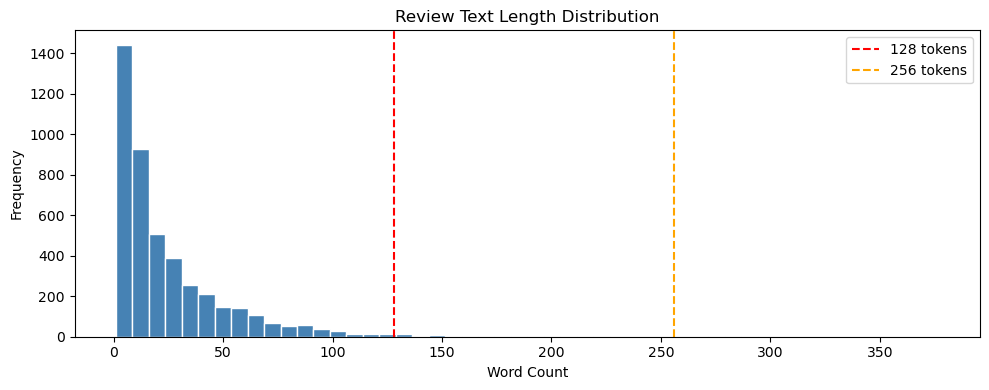

In [25]:
df_transformer['text_length'] = df_transformer['text_clean'].apply(lambda x: len(x.split()))

print(df_transformer['text_length'].describe())
print(f"\nReviews > 512 words: {(df_transformer['text_length'] > 512).sum()}")
print(f"Reviews > 256 words: {(df_transformer['text_length'] > 256).sum()}")
print(f"Reviews > 128 words: {(df_transformer['text_length'] > 128).sum()}")

plt.figure(figsize=(10, 4))
plt.hist(df_transformer['text_length'], bins=50, color='steelblue', edgecolor='white')
plt.axvline(128, color='red', linestyle='--', label='128 tokens')
plt.axvline(256, color='orange', linestyle='--', label='256 tokens')
plt.title('Review Text Length Distribution')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('text_length_distribution.png', dpi=150)
plt.show()